# PBV v5 — Final Proof of Concept

This notebook implements the final PBV proof-of-concept direction from the v1-v4 iteration path.

Core design choices:
- keep the PBV bucket representation from `pbv_v3`
- keep **deep** order book imbalance from levels 2-5 only
- de-emphasize broad `d2` usage and center the final model on cumulative state + `d1`
- replace the old "beats minute-open TWAP" label with a **within-window top-decile** target
- use **argmax-over-window** everywhere as the execution rule
- compare against `pbv_v3` and earlier LR-style baselines with one consistent evaluation path


In [11]:
# ============================================================
# CELL 1: Imports & Config
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

STOCK            = "INTC"
STOCKS_ALL       = ["AMZN", "GOOG", "INTC", "MSFT"]
SIDE             = "SELL"
WARMUP_TICKS     = 30
DEADLINE_S       = 45.0
TRAIN_FRAC       = 0.70
TOP_Q            = 0.90        # top decile within the allowed window
EPS              = 1e-6
RANDOM_STATE     = 42

EXEC_PRICE_COL = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"
OBI_LEVELS     = range(2, 6)

# Final candidate: d1 + cumulative state + deep OBI
FEAT_FINAL = [
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum", "v_ask_near_cum", "v_bid_near_cum",
    "Spread", "elapsed",
    "v_obi", "v_obi_cum",
]

# Baselines for ablation / comparison
FEAT_BASE_LEAN = [
    "v_ask_near_d1", "v_ask_far_d1",
    "v_mid_cum", "v_ask_near_cum", "v_bid_near_cum",
    "Spread", "elapsed",
]
FEAT_WITH_OBI = FEAT_BASE_LEAN + ["v_obi", "v_obi_cum"]
FEAT_WITH_D2  = FEAT_WITH_OBI + ["v_ask_near_d2", "v_bid_near_d2"]

print(f"Side: {SIDE} | Exec col: {EXEC_PRICE_COL}")
print(f"Warmup: {WARMUP_TICKS} ticks | Deadline: {DEADLINE_S}s | Train frac: {TRAIN_FRAC}")
print(f"Target: top {100*(1-TOP_Q):.0f}% of ticks by realized within-window improvement")
print(f"FEAT_BASE_LEAN ({len(FEAT_BASE_LEAN)}): {FEAT_BASE_LEAN}")
print(f"FEAT_WITH_OBI ({len(FEAT_WITH_OBI)}): {FEAT_WITH_OBI}")
print(f"FEAT_WITH_D2 ({len(FEAT_WITH_D2)}): {FEAT_WITH_D2}")
print(f"FEAT_FINAL ({len(FEAT_FINAL)}): {FEAT_FINAL}")


Side: SELL | Exec col: BidPrice_1
Warmup: 30 ticks | Deadline: 45.0s | Train frac: 0.7
Target: top 10% of ticks by realized within-window improvement
FEAT_BASE_LEAN (7): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed']
FEAT_WITH_OBI (9): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum']
FEAT_WITH_D2 (11): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum', 'v_ask_near_d2', 'v_bid_near_d2']
FEAT_FINAL (9): ['v_ask_near_d1', 'v_ask_far_d1', 'v_mid_cum', 'v_ask_near_cum', 'v_bid_near_cum', 'Spread', 'elapsed', 'v_obi', 'v_obi_cum']


In [12]:
# ============================================================
# CELL 2: Data Load + PBV Buckets + Deep OBI + Final Target
# ============================================================
def load_and_compute(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d["Minute"]  = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()
    d["tick_in_minute"] = d.groupby("Minute").cumcount()

    mid = d["MidPrice"]
    b1, a1 = d["BidSize_1"], d["AskSize_1"]

    # Core PBV buckets
    d["v_mid"]      = (b1 - a1) / (b1 + a1 + EPS)
    d["v_ask_near"] = d["AskSize_1"] / (d["AskPrice_1"] - mid).clip(lower=EPS)
    d["v_ask_far"]  = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in range(2, 6))
    d["v_bid_near"] = d["BidSize_1"] / (mid - d["BidPrice_1"]).clip(lower=EPS)
    d["v_bid_far"]  = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in range(2, 6))

    # Deep imbalance: levels 2-5 only
    bid_pressure = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in OBI_LEVELS)
    ask_pressure = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in OBI_LEVELS)
    d["v_obi"] = (bid_pressure - ask_pressure) / (bid_pressure + ask_pressure + EPS)

    bucket_cols = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far", "v_obi"]
    grp = d.groupby("Minute")
    for col in bucket_cols:
        d[f"{col}_cum"] = grp[col].cumsum()
        d[f"{col}_d1"]  = grp[f"{col}_cum"].diff()
        d[f"{col}_d2"]  = grp[f"{col}_d1"].diff()

    # Minute-open TWAP benchmark and realized improvement at each tick
    twap_ref = grp[EXEC_PRICE_COL].transform("first")
    d["twap_ref"] = twap_ref
    d["realized_improvement"] = (twap_ref - d[EXEC_PRICE_COL]) if SIDE == "BUY" else (d[EXEC_PRICE_COL] - twap_ref)

    # Eligibility window for the final execution rule
    d["eligible"] = (d["tick_in_minute"] >= WARMUP_TICKS) & (d["elapsed"] <= DEADLINE_S)

    # Final label: top-decile tick within the allowed window for that minute
    d["label_top_decile"] = 0
    elig = d[d["eligible"]].copy()
    if not elig.empty:
        cutoff = elig.groupby("Minute")["realized_improvement"].transform(lambda s: s.quantile(TOP_Q))
        d.loc[elig.index, "label_top_decile"] = (elig["realized_improvement"].values >= cutoff.values).astype(int)

    d["stock"] = stock
    return d


train_raw = load_and_compute(STOCK)
print(f"Shape: {train_raw.shape} | Minutes: {train_raw['Minute'].nunique()}")
print(f"Eligible ticks: {train_raw['eligible'].sum()} / {len(train_raw)} ({100*train_raw['eligible'].mean():.1f}%)")
print(f"Positive label rate (all rows): {100*train_raw['label_top_decile'].mean():.2f}%")
print(f"Positive label rate (eligible only): {100*train_raw.loc[train_raw['eligible'], 'label_top_decile'].mean():.2f}%")
print(f"corr(v_obi, v_mid) = {train_raw[['v_obi','v_mid']].corr().iloc[0,1]:.3f}")
print(train_raw[["v_obi", "v_obi_cum", "realized_improvement", "label_top_decile"]].describe().round(4))


Shape: (430718, 66) | Minutes: 270
Eligible ticks: 317655 / 430718 (73.8%)
Positive label rate (all rows): 28.00%
Positive label rate (eligible only): 37.97%
corr(v_obi, v_mid) = 0.153
             v_obi    v_obi_cum  realized_improvement  label_top_decile
count  430718.0000  430718.0000           430718.0000        430718.000
mean        0.0527      28.7770               -0.0062             0.280
std         0.1585     371.9432                0.0212             0.449
min        -0.8194   -2377.0499               -0.1300             0.000
25%        -0.0288      -8.5841               -0.0100             0.000
50%         0.0441      20.9236                0.0000             0.000
75%         0.1246      86.4725                0.0000             1.000
max         0.9826    2572.6073                0.0900             1.000


In [13]:
# ============================================================
# CELL 3: Train/Test Split + Feature Matrices
# ============================================================
def build_splits(df, feature_cols):
    df_model = df[df["eligible"]].dropna(subset=feature_cols).copy()
    minutes_sorted = sorted(df_model["Minute"].unique())
    n_train = int(len(minutes_sorted) * TRAIN_FRAC)
    train_mins = set(minutes_sorted[:n_train])
    test_mins  = set(minutes_sorted[n_train:])
    df_train = df_model[df_model["Minute"].isin(train_mins)].copy()
    df_test  = df_model[df_model["Minute"].isin(test_mins)].copy()
    return df_model, df_train, df_test, train_mins, test_mins


df_model, df_train, df_test, train_mins, test_mins = build_splits(train_raw, FEAT_WITH_D2)
print(f"Post-window rows: {len(df_model)}")
print(f"Train: {len(train_mins)} minutes, {len(df_train)} rows, label={100*df_train['label_top_decile'].mean():.2f}%")
print(f"Test : {len(test_mins)} minutes, {len(df_test)} rows, label={100*df_test['label_top_decile'].mean():.2f}%")


Post-window rows: 317655
Train: 189 minutes, 247899 rows, label=35.62%
Test : 81 minutes, 69756 rows, label=46.31%


In [14]:
# ============================================================
# CELL 4: Fit Models — Lean vs +OBI vs +OBI+d2
# ============================================================
def fit_model(feat_cols, df_tr, df_te):
    sc = StandardScaler()
    Xtr = sc.fit_transform(df_tr[feat_cols].values)
    Xte = sc.transform(df_te[feat_cols].values)
    ytr = df_tr["label_top_decile"].values
    yte = df_te["label_top_decile"].values

    model = LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    model.fit(Xtr, ytr)
    tr_auc = roc_auc_score(ytr, model.predict_proba(Xtr)[:, 1])
    te_auc = roc_auc_score(yte, model.predict_proba(Xte)[:, 1])
    return model, sc, tr_auc, te_auc


model_specs = {
    "lean_pbv": FEAT_BASE_LEAN,
    "lean_pbv_plus_obi": FEAT_WITH_OBI,
    "lean_pbv_plus_obi_plus_d2": FEAT_WITH_D2,
}

fit_results = {}
for name, feats in model_specs.items():
    fit_results[name] = fit_model(feats, df_train, df_test)

print(f"{'Model':<28} {'Features':>8}  {'Train AUC':>10}  {'Test AUC':>9}")
print("-" * 64)
for name, feats in model_specs.items():
    _, _, tr_auc, te_auc = fit_results[name]
    print(f"{name:<28} {len(feats):>8}  {tr_auc:>10.4f}  {te_auc:>9.4f}")

best_name = max(model_specs, key=lambda k: fit_results[k][3])
print(f"\nBest test-AUC model: {best_name}")

m_final, sc_final, _, _ = fit_results[best_name]
coef_df = pd.DataFrame({"feature": model_specs[best_name], "coef": m_final.coef_[0]})
coef_df = coef_df.sort_values("coef")
print("\nFinal-model coefficients:")
print(coef_df.to_string(index=False, float_format=lambda x: f"{x:0.4f}"))


Model                        Features   Train AUC   Test AUC
----------------------------------------------------------------
lean_pbv                            7      0.7958     0.7444
lean_pbv_plus_obi                   9      0.8009     0.7202
lean_pbv_plus_obi_plus_d2          11      0.8009     0.7202

Best test-AUC model: lean_pbv

Final-model coefficients:
       feature    coef
v_ask_near_cum -1.3480
        Spread -0.5976
       elapsed  0.0863
 v_ask_near_d1  0.2116
v_bid_near_cum  0.2514
     v_mid_cum  0.2948
  v_ask_far_d1  0.6627


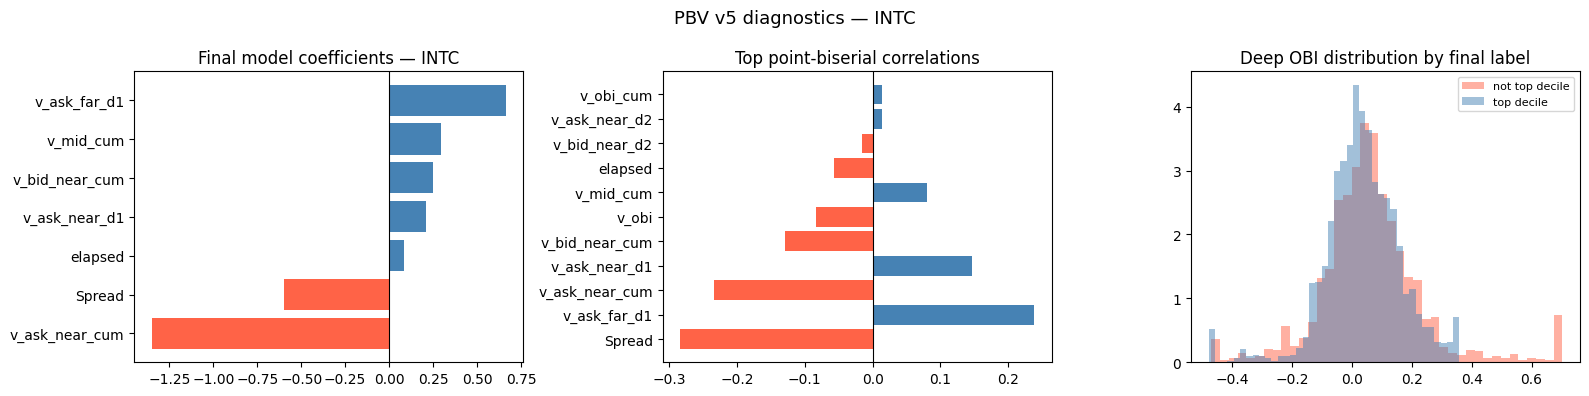

Top feature correlations with final label:
Spread           -0.2836
v_ask_far_d1      0.2381
v_ask_near_cum   -0.2343
v_ask_near_d1     0.1469
v_bid_near_cum   -0.1289
v_obi            -0.0840
v_mid_cum         0.0798
elapsed          -0.0575
v_bid_near_d2    -0.0152
v_ask_near_d2     0.0136
v_obi_cum         0.0132


In [15]:
# ============================================================
# CELL 5: Single-Stock Diagnostics
# ============================================================
all_feat = sorted(set(FEAT_WITH_D2))
feat_corr = train_raw.loc[train_raw['eligible'], all_feat + ['label_top_decile']].corr()['label_top_decile'].drop('label_top_decile')
feat_corr = feat_corr.sort_values(key=np.abs, ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

coef_colors = ["darkorange" if "obi" in f else ("steelblue" if c > 0 else "tomato") for f, c in zip(coef_df['feature'], coef_df['coef'])]
axes[0].barh(coef_df['feature'], coef_df['coef'], color=coef_colors, edgecolor='none')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title(f"Final model coefficients — {STOCK}")

axes[1].barh(feat_corr.index[:12], feat_corr.values[:12], color=["steelblue" if v > 0 else "tomato" for v in feat_corr.values[:12]], edgecolor='none')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title("Top point-biserial correlations")

plot_df = train_raw.loc[train_raw['eligible'], ['v_mid', 'v_obi', 'label_top_decile']].copy()
for label, color, name in [(0, 'tomato', 'not top decile'), (1, 'steelblue', 'top decile')]:
    vals = plot_df.loc[plot_df['label_top_decile'] == label, 'v_obi']
    vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
    axes[2].hist(vals, bins=40, alpha=0.5, density=True, color=color, label=name, edgecolor='none')
axes[2].set_title("Deep OBI distribution by final label")
axes[2].legend(fontsize=8)

plt.suptitle(f"PBV v5 diagnostics — {STOCK}", fontsize=13)
plt.tight_layout()
plt.show()

print("Top feature correlations with final label:")
print(feat_corr.head(15).round(4).to_string())


In [16]:
# ============================================================
# CELL 6: Shared Simulation Functions
# ============================================================
def simulate_argmax(model, scaler, feat_cols, df_features, df_raw):
    df_s = df_features.copy()
    df_s['prob'] = model.predict_proba(scaler.transform(df_s[feat_cols].values))[:, 1]

    rows = []
    for minute, grp in df_s.groupby('Minute'):
        window = grp.sort_values('elapsed')
        twap_price = df_raw.loc[df_raw['Minute'] == minute, 'twap_ref'].iloc[0]
        exec_row = window.loc[window['prob'].idxmax()]
        oracle_row = window.loc[window['realized_improvement'].idxmax()]

        rows.append({
            'Minute': minute,
            'twap_price': twap_price,
            'pbv_price': exec_row[EXEC_PRICE_COL],
            'exec_s': exec_row['elapsed'],
            'score': exec_row['prob'],
            'improvement': exec_row['realized_improvement'],
            'oracle_improvement': oracle_row['realized_improvement'],
            'oracle_gap': oracle_row['realized_improvement'] - exec_row['realized_improvement'],
        })
    return pd.DataFrame(rows)


def simulate_v3_baseline(df_raw, test_minutes):
    rows = []
    df_v3 = df_raw[df_raw['Minute'].isin(test_minutes)].copy()
    for minute, grp in df_v3.groupby('Minute'):
        grp = grp.sort_values('elapsed')
        twap_price = grp['twap_ref'].iloc[0]
        signal = (
            (grp['tick_in_minute'] >= WARMUP_TICKS) &
            (grp['v_ask_near_d2'] < 0) &
            (grp['v_mid_cum'] > 0)
        ).fillna(False)
        fired = grp[signal & (grp['elapsed'] <= DEADLINE_S)]
        if not fired.empty:
            exec_row = fired.iloc[0]
        else:
            eligible = grp[grp['eligible']]
            if eligible.empty:
                idx = (grp['elapsed'] - DEADLINE_S).abs().idxmin()
                exec_row = grp.loc[idx]
            else:
                idx = eligible['elapsed'].sub(DEADLINE_S).abs().idxmin()
                exec_row = eligible.loc[idx]

        eligible_for_oracle = grp[grp['eligible']]
        oracle_row = eligible_for_oracle.loc[eligible_for_oracle['realized_improvement'].idxmax()] if not eligible_for_oracle.empty else exec_row
        rows.append({
            'Minute': minute,
            'twap_price': twap_price,
            'pbv_price': exec_row[EXEC_PRICE_COL],
            'exec_s': exec_row['elapsed'],
            'score': np.nan,
            'improvement': exec_row['realized_improvement'],
            'oracle_improvement': oracle_row['realized_improvement'],
            'oracle_gap': oracle_row['realized_improvement'] - exec_row['realized_improvement'],
        })
    return pd.DataFrame(rows)


def summarize_results(label, res_df, auc=np.nan):
    return {
        'Model': label,
        'AUC': auc,
        'Mean $': res_df['improvement'].mean(),
        'Median $': res_df['improvement'].median(),
        'Beat %': 100 * (res_df['improvement'] > 0).mean(),
        'Exec s': res_df['exec_s'].mean(),
        'Oracle $': res_df['oracle_improvement'].mean(),
        'Oracle gap $': res_df['oracle_gap'].mean(),
    }


                    Model     AUC   Mean $  Median $   Beat %   Exec s  Oracle $  Oracle gap $
                 lean_pbv 0.74437  0.00062   0.00000 16.04938 12.59981   0.00407       0.00346
        lean_pbv_plus_obi 0.72017  0.00049   0.00000 17.28395 14.15248   0.00407       0.00358
lean_pbv_plus_obi_plus_d2 0.72023  0.00148   0.00000 20.98765 15.22638   0.00407       0.00259
         v3_rule_baseline     NaN -0.00185   0.00000  2.46914 18.79109   0.00407       0.00593


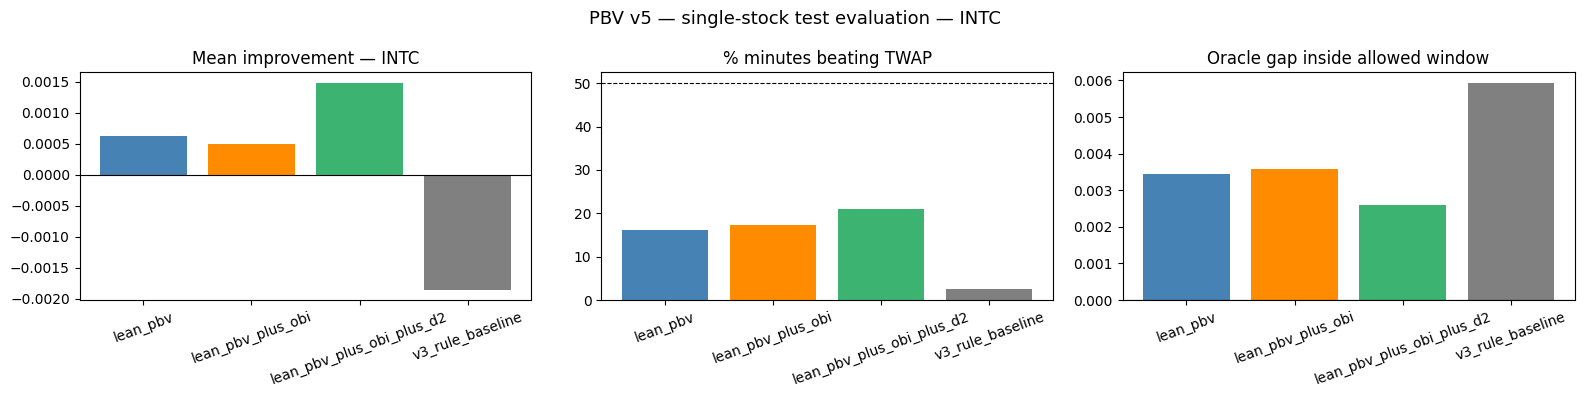

In [17]:
# ============================================================
# CELL 7: Single-Stock Evaluation — Final vs Baselines
# ============================================================
# Rebuild per-model test sets with the proper feature subsets
single_stock_rows = []
res_map = {}
for name, feats in model_specs.items():
    _, _, _, te_auc = fit_results[name]
    _, _, df_te_model, _, test_mins_local = build_splits(train_raw, feats)
    model, scaler, _, _ = fit_results[name]
    res = simulate_argmax(model, scaler, feats, df_te_model, train_raw)
    res_map[name] = res
    single_stock_rows.append(summarize_results(name, res, auc=te_auc))

res_v3 = simulate_v3_baseline(train_raw, test_mins_local)
res_map['v3_rule_baseline'] = res_v3
single_stock_rows.append(summarize_results('v3_rule_baseline', res_v3, auc=np.nan))

single_stock_summary = pd.DataFrame(single_stock_rows)
print(single_stock_summary.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = single_stock_summary['Model']
colors = ['steelblue','darkorange','mediumseagreen','gray']

axes[0].bar(labels, single_stock_summary['Mean $'], color=colors)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title(f"Mean improvement — {STOCK}")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, single_stock_summary['Beat %'], color=colors)
axes[1].axhline(50, color='black', lw=0.8, ls='--')
axes[1].set_title('% minutes beating TWAP')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(labels, single_stock_summary['Oracle gap $'], color=colors)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Oracle gap inside allowed window')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle(f"PBV v5 — single-stock test evaluation — {STOCK}", fontsize=13)
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# CELL 8: Cross-Stock Evaluation
# ============================================================
def run_stock(stock):
    d = load_and_compute(stock)
    out = {}

    # Learned-model variants
    for name, feats in model_specs.items():
        _, df_tr, df_te, _, test_mins = build_splits(d, feats)
        model, scaler, tr_auc, te_auc = fit_model(feats, df_tr, df_te)
        res = simulate_argmax(model, scaler, feats, df_te, d)
        out[name] = summarize_results(name, res, auc=te_auc)

    # v3 rule baseline on the same test minutes
    out['v3_rule_baseline'] = summarize_results('v3_rule_baseline', simulate_v3_baseline(d, test_mins), auc=np.nan)
    return out


print('Running cross-stock PBV v5 pipeline...')
xs = {s: run_stock(s) for s in STOCKS_ALL}
print('Done.')

rows = []
for stock in STOCKS_ALL:
    for model_name in ['lean_pbv', 'lean_pbv_plus_obi', 'lean_pbv_plus_obi_plus_d2', 'v3_rule_baseline']:
        r = xs[stock][model_name]
        rows.append({
            'Stock': stock,
            'Model': model_name,
            **r,
        })

xs_df = pd.DataFrame(rows)
print(xs_df[['Stock','Model','AUC','Mean $','Median $','Beat %','Exec s','Oracle gap $']].to_string(index=False, float_format=lambda x: f"{x:0.5f}"))


Running cross-stock PBV v5 pipeline...
Done.
Stock                     Model     AUC   Mean $  Median $   Beat %   Exec s  Oracle gap $
 AMZN                  lean_pbv 0.68389  0.01074   0.01000 55.55556 25.40204       0.04444
 AMZN         lean_pbv_plus_obi 0.68476  0.01531   0.01000 53.08642 24.88835       0.03988
 AMZN lean_pbv_plus_obi_plus_d2 0.68477  0.01531   0.01000 53.08642 24.89467       0.03988
 AMZN          v3_rule_baseline     NaN -0.01235   0.00000 38.27160 15.96509       0.06753
 GOOG                  lean_pbv 0.64985  0.06556   0.06000 62.96296 20.65043       0.06654
 GOOG         lean_pbv_plus_obi 0.68251  0.07037   0.06000 65.43210 20.94843       0.06173
 GOOG lean_pbv_plus_obi_plus_d2 0.68314  0.06889   0.06000 66.66667 21.58857       0.06321
 GOOG          v3_rule_baseline     NaN -0.01370   0.00000 39.50617 21.15237       0.14580
 INTC                  lean_pbv 0.74437  0.00062   0.00000 16.04938 12.59981       0.00346
 INTC         lean_pbv_plus_obi 0.72017  0.00

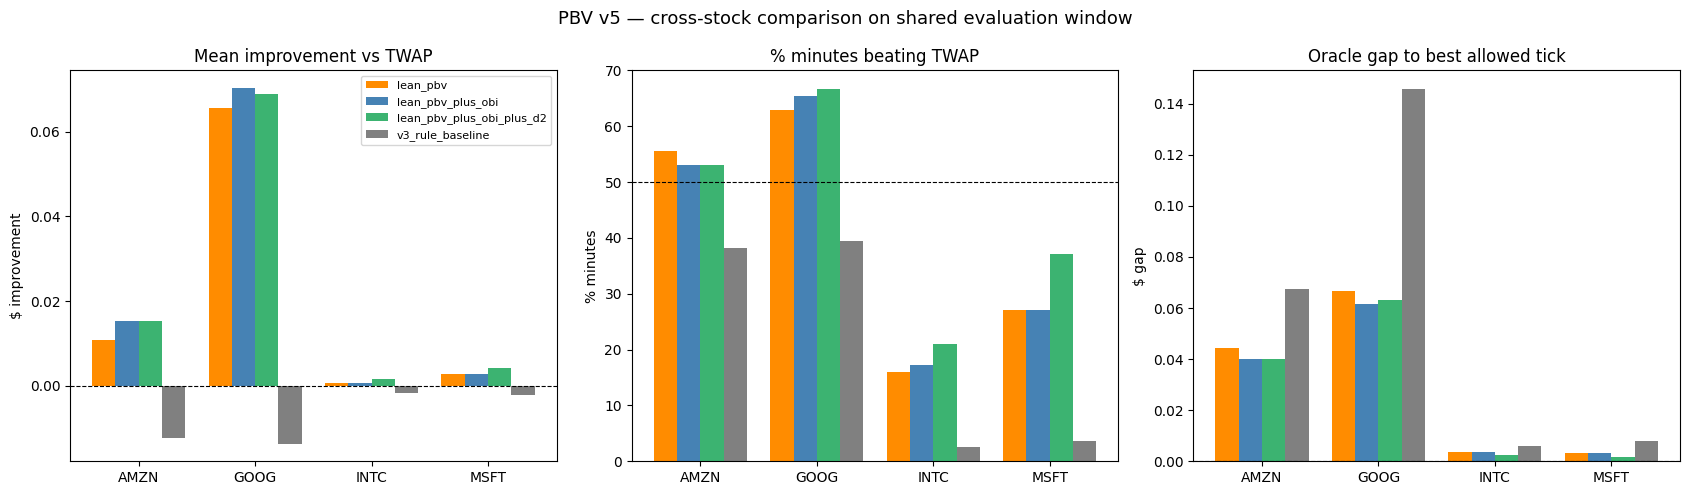

In [19]:
# ============================================================
# CELL 9: Cross-Stock Visual Summary
# ============================================================
plot_models = ['lean_pbv', 'lean_pbv_plus_obi', 'lean_pbv_plus_obi_plus_d2', 'v3_rule_baseline']
plot_colors = {
    'lean_pbv': 'darkorange',
    'lean_pbv_plus_obi': 'steelblue',
    'lean_pbv_plus_obi_plus_d2': 'mediumseagreen',
    'v3_rule_baseline': 'gray',
}

x = np.arange(len(STOCKS_ALL))
width = 0.2
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for j, (metric, ylabel, title) in enumerate([
    ('Mean $', '$ improvement', 'Mean improvement vs TWAP'),
    ('Beat %', '% minutes', '% minutes beating TWAP'),
    ('Oracle gap $', '$ gap', 'Oracle gap to best allowed tick'),
]):
    ax = axes[j]
    for i, model_name in enumerate(plot_models):
        vals = [xs[s][model_name][metric] for s in STOCKS_ALL]
        ax.bar(x + (i - 1.5) * width, vals, width, label=model_name, color=plot_colors[model_name])
    ax.axhline(0 if metric != 'Beat %' else 50, color='black', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(STOCKS_ALL)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].legend(fontsize=8)
plt.suptitle('PBV v5 — cross-stock comparison on shared evaluation window', fontsize=13)
plt.tight_layout()
plt.show()


## Notes

- This notebook intentionally stops at the final proof-of-concept implementation implied by the `pbv` through `v4` iteration path.
- The final label is **window-aware** and the execution rule is **argmax-over-window**, so the training target and execution logic are aligned.
- The `v3` baseline is retained as the interpretable hand-crafted comparator.
- The deep-OBI feature is kept only in levels 2-5 to avoid collapsing back into top-of-book imbalance.
